In [7]:
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.cm import get_cmap 

plt.rcParams['figure.figsize'] = [8,8] 
plt.rcParams.update({'font.size': 18}) 

# Define domain 
dx = 0.001 
L = np.pi 
x = L * np.arange(-1+dx, 1+dx, dx) 
n = len(x) 
nquart = int(np.floor(n/4)) 

C:\Users\Troy\AppData\Local\Temp\ipykernel_16972\1960772541.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')


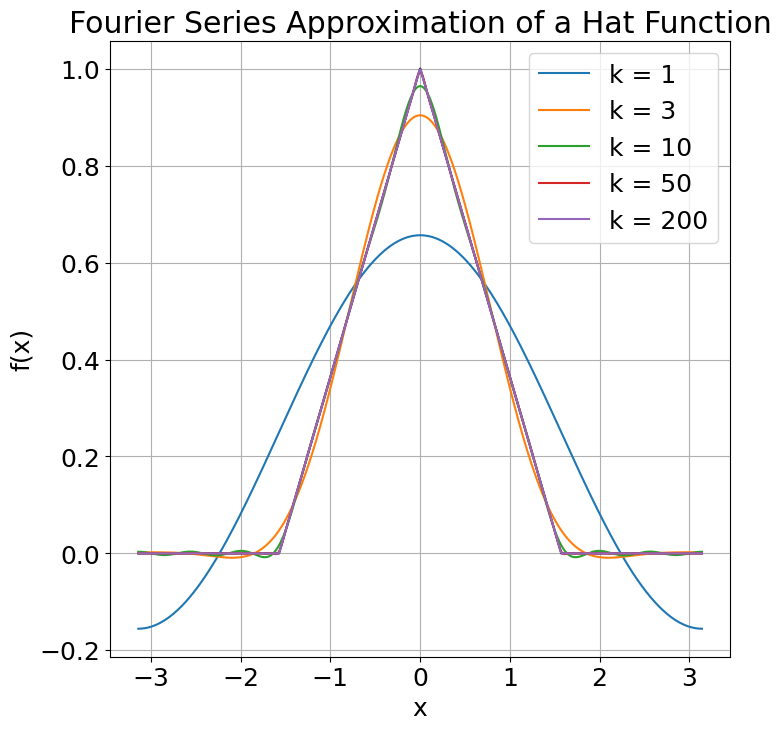

In [8]:
# Define hat function 
f = np.zeros_like(x) 
f[nquart:2*nquart] = (4/n)*np.arange(1, nquart+1) 
f[2*nquart:3*nquart] = np.ones(nquart) - (4/n)*np.arange(0, nquart) 

fig, ax = plt.subplots() 
ax.plot(x, f, '-', color='k') 

# Compute Fourier series 
name = 'Accent' 
cmap = get_cmap('tab10') 
colors = cmap.colors 
ax.set_prop_cycle(color=colors) 

# Calculate Fourier Coefficients 
A0 = np.sum(f * np.ones_like(x)) * dx 
fFS = A0 / 2 

# Iterate to compute and plot the Fourier series for various terms
k_max = 200 
A = np.zeros(k_max) 
B = np.zeros(k_max) 

plot_steps = [1, 3, 10, 50, 200]

for k in range(k_max):
    # Compute the coefficients using the continuous projection 
    A[k] = np.sum(f * np.cos((k+1) * x * np.pi / L)) * dx 
    B[k] = np.sum(f * np.sin((k+1) * x * np.pi / L)) * dx 
    
    # Update the Fourier series approximation
    fFS = fFS + A[k]*np.cos((k+1)*x*np.pi/L) + B[k]*np.sin((k+1)*x*np.pi/L)
    
    # Plot selected number of terms
    if (k+1) in plot_steps:
        ax.plot(x, fFS, '-', label=f'k = {k+1}')

ax.set_title(f'Fourier Series Approximation of a Hat Function')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend(loc='upper right')
ax.grid(True)
plt.show()